# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

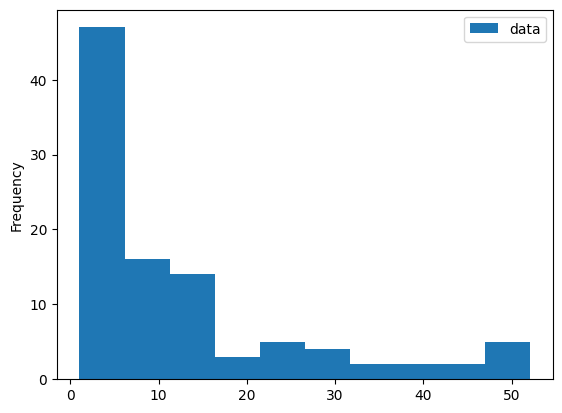

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

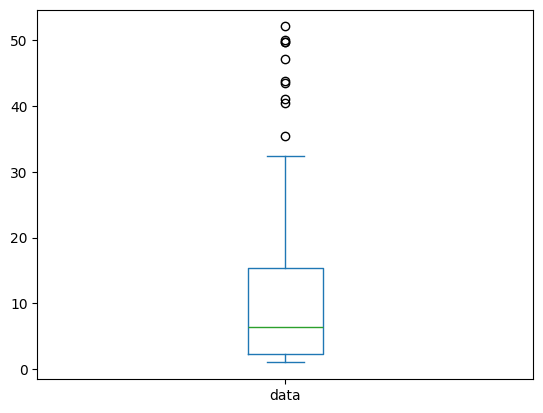

In [3]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [6]:
SAMPLE_SIZE = 15000 # some of the data sets are large 


   

def load_csv_sampled(filepath, sample_size=SAMPLE_SIZE, random_state=42, sep=None, encoding=None, **kwargs):
    # try encodings in order
    encodings = [encoding] if encoding else ['utf-8', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            # auto-detect delimiter
            if sep is None:
                with open(filepath, 'r', encoding=enc) as f:
                    first_line = f.readline()
                    sep = '\t' if '\t' in first_line else ','
            
            row_count = sum(1 for _ in open(filepath, encoding=enc)) - 1
            
            if sample_size and row_count > sample_size:
                np.random.seed(random_state)
                skip_idx = np.random.choice(range(1, row_count + 1), size=int(row_count * (1 - sample_size/row_count)), replace=False)
                df = pd.read_csv(filepath, skiprows=skip_idx, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows (sampled from {row_count:,}) [encoding: {enc}]")
            else:
                df = pd.read_csv(filepath, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows [encoding: {enc}]")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError(f"Could not decode file with encodings: {encodings}")

In [7]:
df_us_ecommerce_records_sample = load_csv_sampled("data_us_ecommerce_records.csv")

Loaded 3,312 rows [encoding: latin-1]


In [8]:
# Load Data using default sample 
# instacart is 3Million records so we are just going to use about 50K
df_instacart_sample = load_csv_sampled("data_instacart_combined.csv")

Loaded 15,000 rows (sampled from 33,819,106) [encoding: utf-8]


In [10]:
print(f"us_ecommerce_records {df_us_ecommerce_records_sample.columns}") 
print(f"instacart {df_instacart_sample.columns}") 

us_ecommerce_records Index(['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')
instacart Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'eval_set', 'product_id', 'product_name',
       'aisle_id', 'aisle', 'department_id', 'department', 'add_to_cart_order',
       'reordered'],
      dtype='object')


In [129]:
## helpers
import matplotlib.pyplot as plt
import seaborn as sns


def plot_histogram(df, feature, ax, bins=30):
    data = df[feature].dropna()
    _= ax.hist(data, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set(title=f'Histogram — {feature}', xlabel=feature, ylabel='Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.legend(fontsize=8)
    return ax

def plot_kde(df, feature, ax):
    data = df[feature].dropna()
    sns.kdeplot(data, ax=ax, fill=True, color='teal', alpha=0.4, linewidth=2)
    ax.set(title=f'KDE — {feature}', xlabel=feature, ylabel='Density')
    return ax

def plot_swarm(df, feature, ax, sample_n=500):
    data = df[feature].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    _ = sns.swarmplot(y=data, ax=ax, color='coral', size=2.5, alpha=0.7)
    ax.set(title=f'Swarm — {feature} (n={len(data)})', ylabel=feature)
    return ax

def plot_violin(df, feature, ax):
    _ =  sns.violinplot(y=df[feature].dropna(), ax=ax, color='mediumpurple',
                   inner='box', linewidth=1.2)
    ax.set(title=f'Violin — {feature}', ylabel=feature)
    return ax

def plot_categorical_bar_chart(df, feature, ax):
    df[feature].value_counts().head(20).plot(kind='bar', ax=ax, color='goldenrod', edgecolor='white')
    ax.set(title=f'Value Counts — {feature}', xlabel=feature, ylabel='Count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

def plot_bin_sensitivity(df, feature):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, bins in zip(axes, [5, 15, 30, 100]):
        ax.hist(df[feature].dropna(), bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
        ax.set(title=f'{bins} bins', xlabel=feature, ylabel='Count')
    plt.suptitle(f'Bin Sensitivity — {feature}')
    plt.tight_layout()
    plt.show()

def plot_numeric_univariate(df, feature): #Univariate Numeric -> histogram + kde + violin + swarm
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    plot_histogram(df, feature, ax=axes[0])
    plot_kde(df, feature, ax=axes[1])
    plot_swarm(df, feature, ax=axes[2])
    plot_violin(df, feature, ax=axes[3])
    plt.tight_layout()
    plt.show()

    plot_bin_sensitivity(df, feature)  # <-- add this
    
def plot_categorical_univariate(df, feature): #Univariate Categorical       # value counts bar
     fig, ax = plt.subplots(figsize=(12, 4))
     plot_categorical_bar_chart(df, feature, ax)



def plot_grouped_multi_variate(df, groupings):
    fig, axes = plt.subplots(1, len(groupings), figsize=(6 * len(groupings), 4))
    if len(groupings) == 1:
        axes = [axes]
    for ax, (feature, group_by) in zip(axes, groupings):
        for group in df[group_by].unique():
            data = df[df[group_by] == group][feature].dropna()
            sns.kdeplot(data, ax=ax, fill=True, alpha=0.3, label=group, linewidth=2)
        ax.set(title=f'{feature} by {group_by}', xlabel=feature, ylabel='Density')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe().T)
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe().T)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [135]:
skip_patterns = ['_id', ' id', 'row', 'postal', 'city', 'state', 'name', 'date', 'number'] ## skip columns that are not good for charting 
def analyze_dataset(df, groups, dataset_name='Dataset', bins=30, sample_n=500):

    print(f"{'='*100}")
    print(f"  {dataset_name}")
    print(f"{'='*100}")

    summarize_df(df)
    
    print("\n--- Numeric Features ---")
    for col in df.select_dtypes(include='number').columns:
        if not any(p in col.lower() for p in skip_patterns):
            plot_numeric_univariate(df, col)

    print("\n--- Categorical Features ---")
    for col in df.select_dtypes(include=['object', 'category']).columns:
      if not any(p in col.lower() for p in skip_patterns):
        plot_categorical_univariate(df, col)

    print("\n--- Grouped Features ---")
    plot_grouped_multi_variate(df,groups)




### Analysis

  US E-Commerce Records
Shape: 3,312 x 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null  

,count,mean,std,min,25%,50%,75%,max
Row ID,3312.0,5087.107488,2817.482266,13.0000,2655.7500,5183.5000,7498.250000,9994.0000
Postal Code,3312.0,56186.515097,31980.375516,1841.0000,27978.7500,60472.5000,90032.000000,99301.0000
Sales,3312.0,221.381418,585.257531,0.4440,17.0180,53.8100,205.105700,13999.9600
Quantity,3312.0,3.766908,2.221776,1.0000,2.0000,3.0000,5.000000,14.0000
Discount,3312.0,0.156467,0.207429,0.0000,0.0000,0.2000,0.200000,0.8000
Profit,3312.0,28.212340,241.864342,-3839.9904,1.7632,8.2968,28.315125,6719.9808


Categorical


,count,unique,top,freq
Order Date,3312,322,02-09-20,36
Order ID,3312,1687,CA-2017-100111,14
Ship Mode,3312,4,Standard Class,1897
Customer ID,3312,693,SV-20365,20
Segment,3312,3,Consumer,1668
Country,3312,1,United States,3312
City,3312,350,New York City,306
State,3312,47,California,663
Region,3312,4,West,1095
Product ID,3312,1525,FUR-CH-10003774,8



--- Grouped Features ---


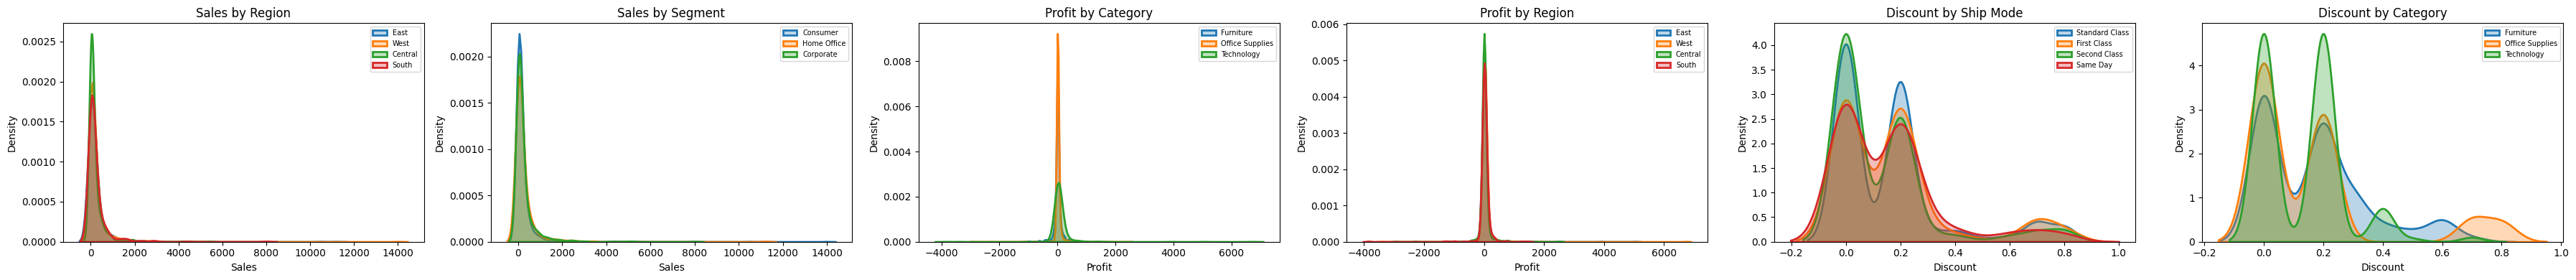

In [132]:

us_ds_groupings = [
    ('Sales', 'Region'),
    ('Sales', 'Segment'),
    ('Profit', 'Category'),
    ('Profit', 'Region'),       
    ('Discount', 'Ship Mode'),
    ('Discount', 'Category'),  
]

analyze_dataset(df_us_ecommerce_records_sample,us_ds_groupings, dataset_name='US E-Commerce Records')

  Instacart Records
Shape: 15,000 x 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                15000 non-null  int64  
 1   user_id                 15000 non-null  int64  
 2   order_number            15000 non-null  int64  
 3   order_dow               15000 non-null  int64  
 4   order_hour_of_day       15000 non-null  int64  
 5   days_since_prior_order  14033 non-null  float64
 6   eval_set                15000 non-null  object 
 7   product_id              15000 non-null  int64  
 8   product_name            15000 non-null  object 
 9   aisle_id                15000 non-null  int64  
 10  aisle                   15000 non-null  object 
 11  department_id           15000 non-null  int64  
 12  department              15000 non-null  object 
 13  add_to_cart_order       15000 non-null  int64  
 14 

,count,mean,std,min,25%,50%,75%,max
order_id,15000.0,1.713993e+06,987912.279299,338.0,867760.0,1710494.5,2564290.0,3421055.0
user_id,15000.0,1.028657e+05,59495.831027,14.0,51428.5,102922.5,154372.0,206201.0
order_number,15000.0,1.713873e+01,17.439523,1.0,5.0,11.0,24.0,100.0
order_dow,15000.0,2.716000e+00,2.098135,0.0,1.0,2.0,5.0,6.0
order_hour_of_day,15000.0,1.345987e+01,4.247508,0.0,10.0,13.0,16.0,23.0
days_since_prior_order,14033.0,1.142001e+01,8.971871,0.0,5.0,8.0,15.0,30.0
product_id,15000.0,2.554349e+04,14071.577366,1.0,13565.0,25309.0,37937.0,49683.0
aisle_id,15000.0,7.113147e+01,38.091507,1.0,31.0,83.0,107.0,134.0
department_id,15000.0,9.897000e+00,6.302008,1.0,4.0,8.0,16.0,21.0
add_to_cart_order,15000.0,8.257400e+00,7.055508,1.0,3.0,6.0,11.0,66.0


Categorical


,count,unique,top,freq
eval_set,15000,2,prior,14377
product_name,15000,5917,Banana,221
aisle,15000,134,fresh fruits,1661
department,15000,21,produce,4408



--- Numeric Features ---


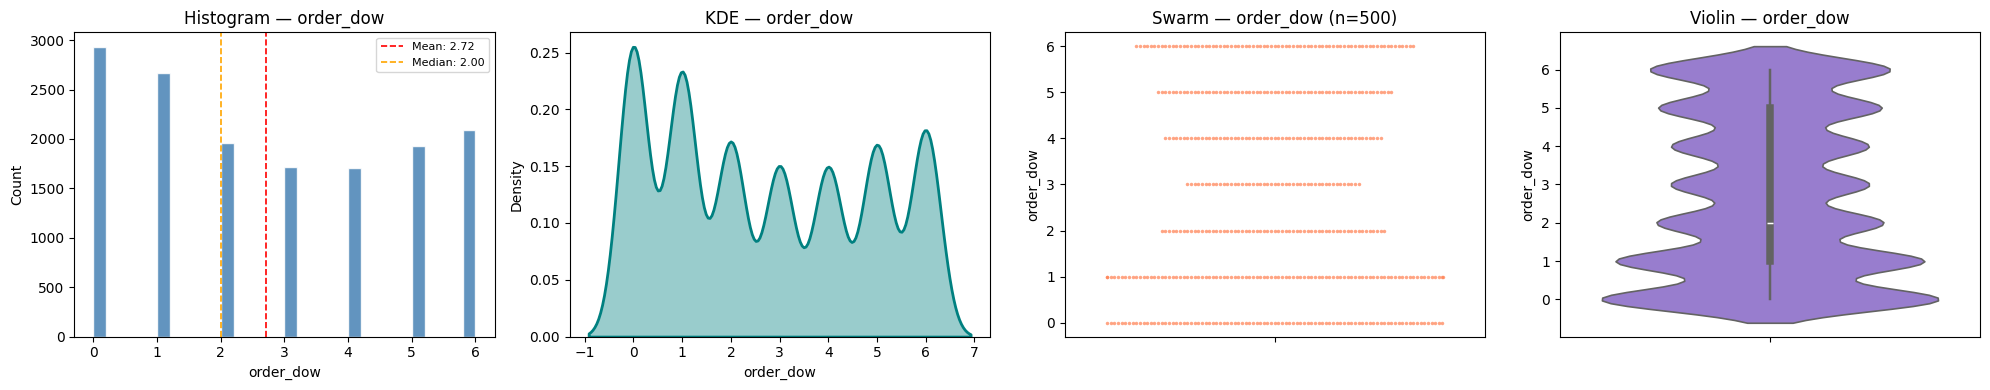

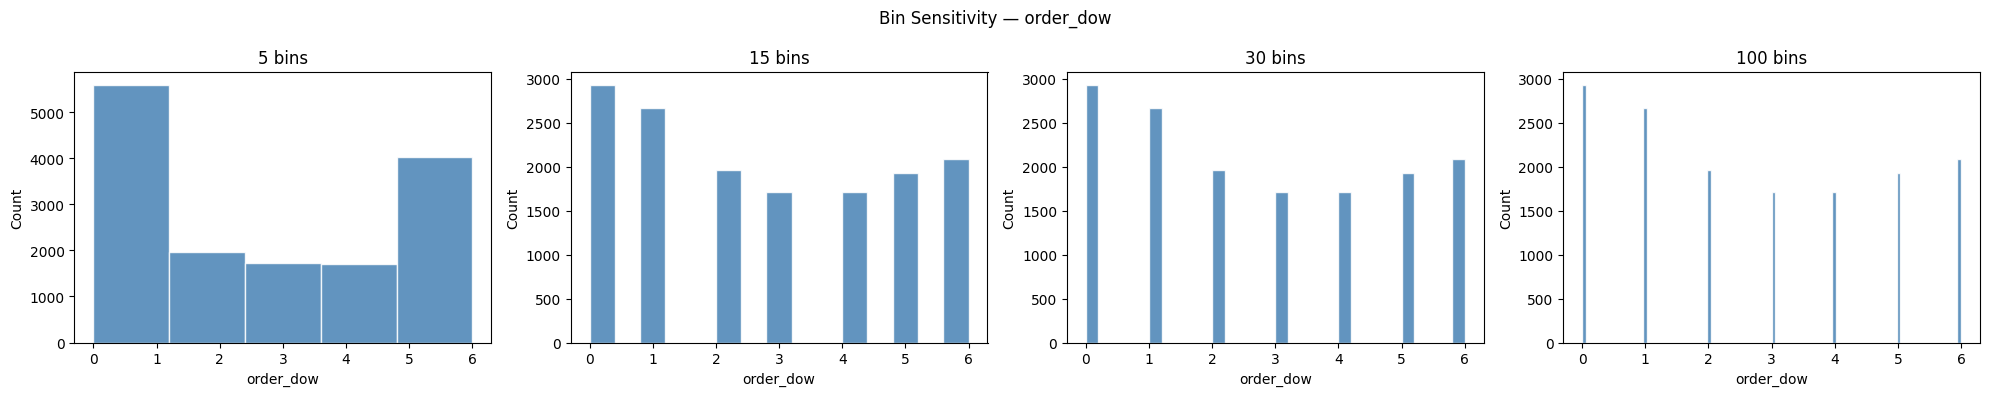

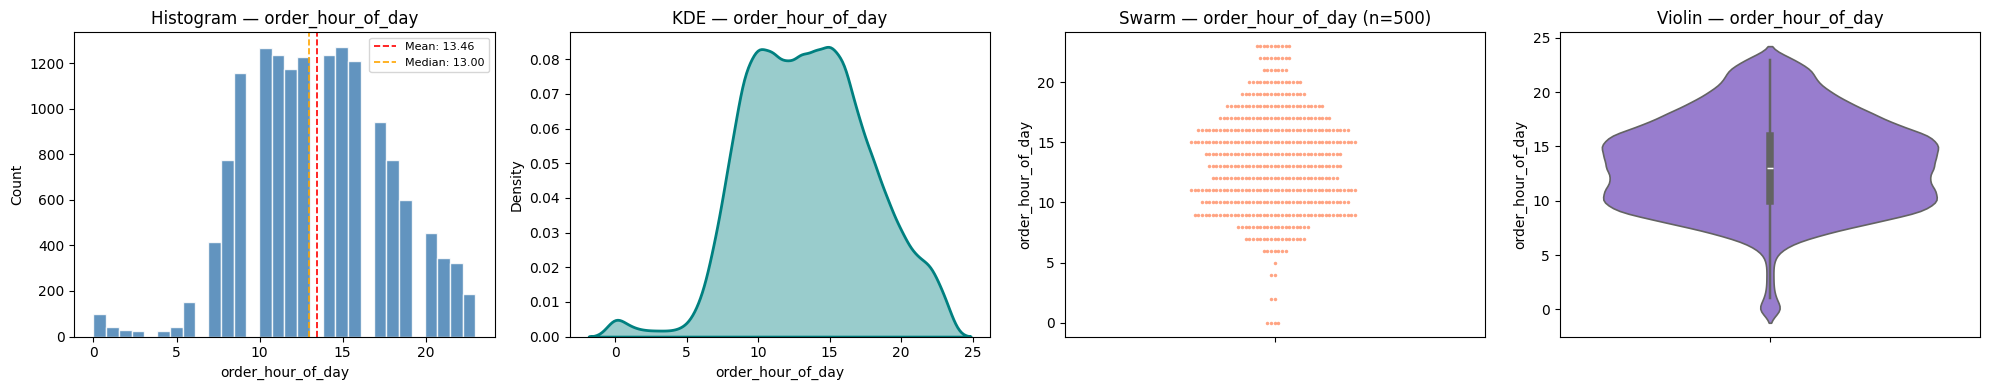

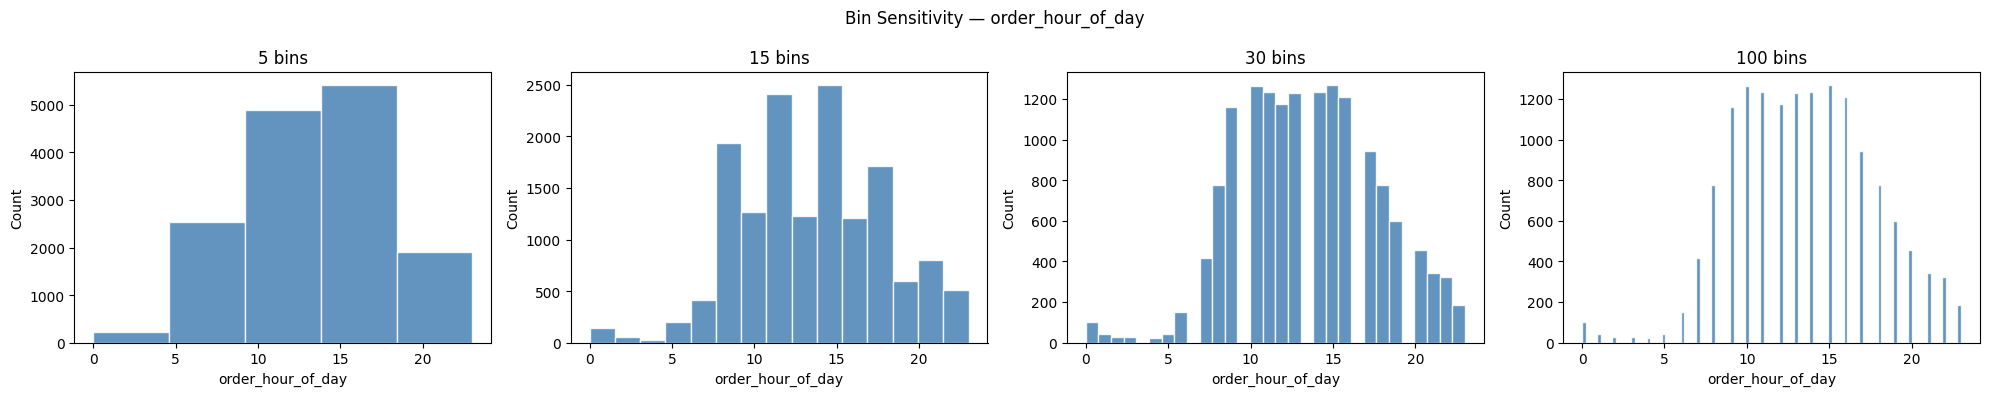

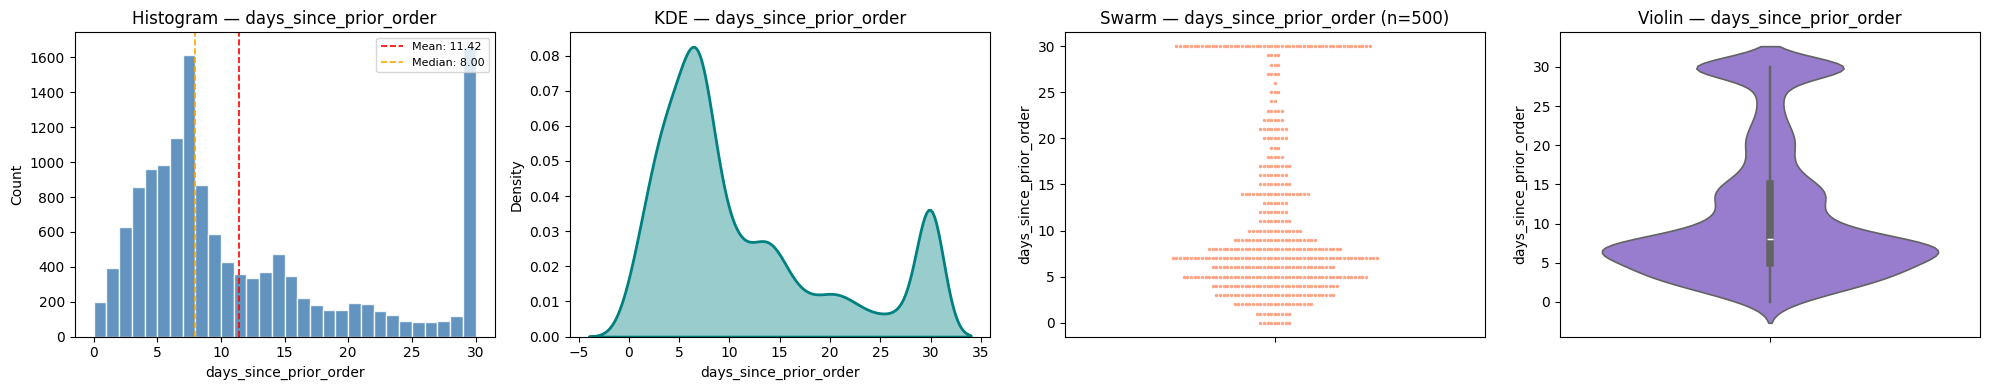

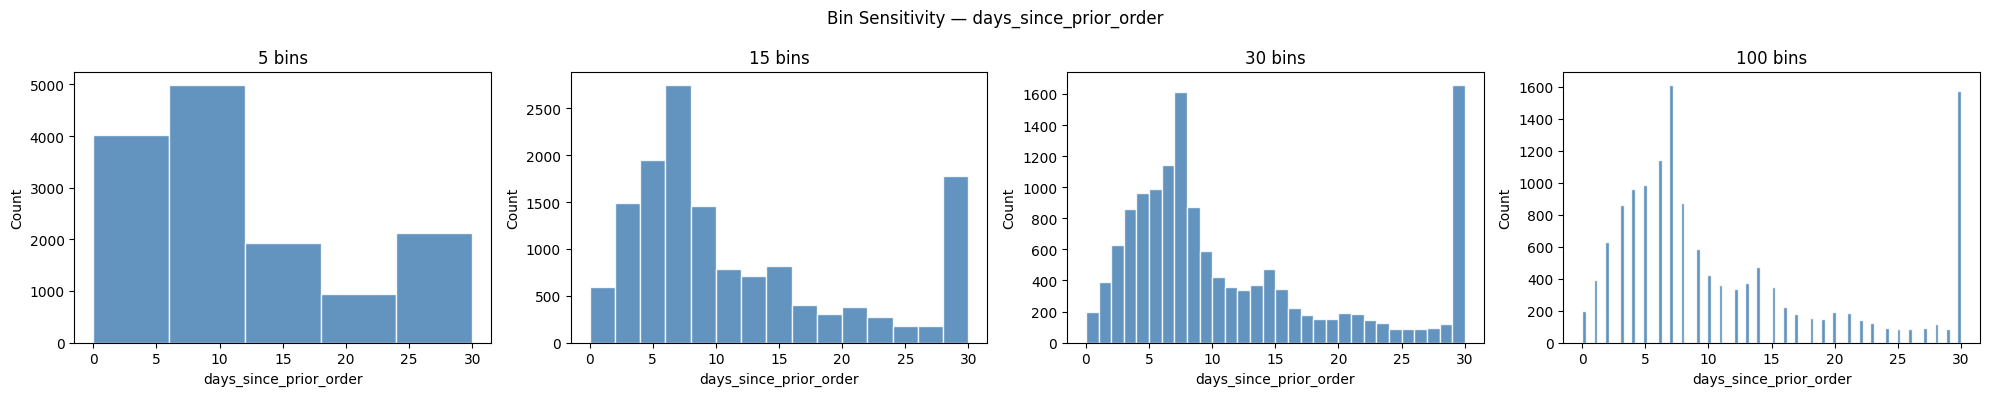

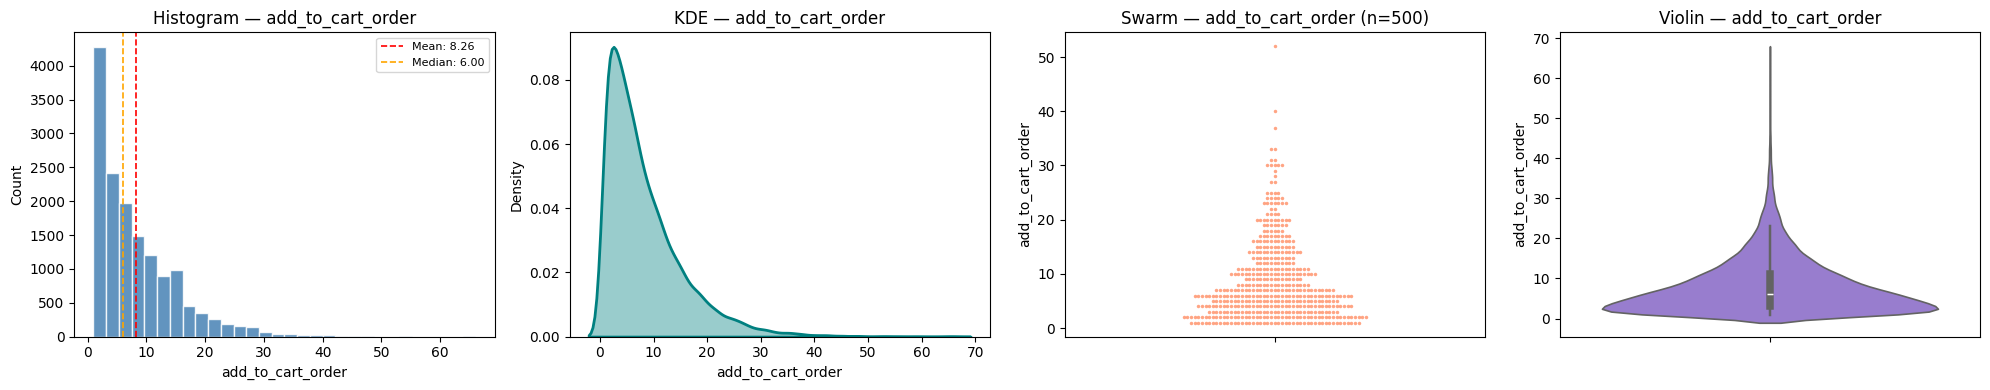

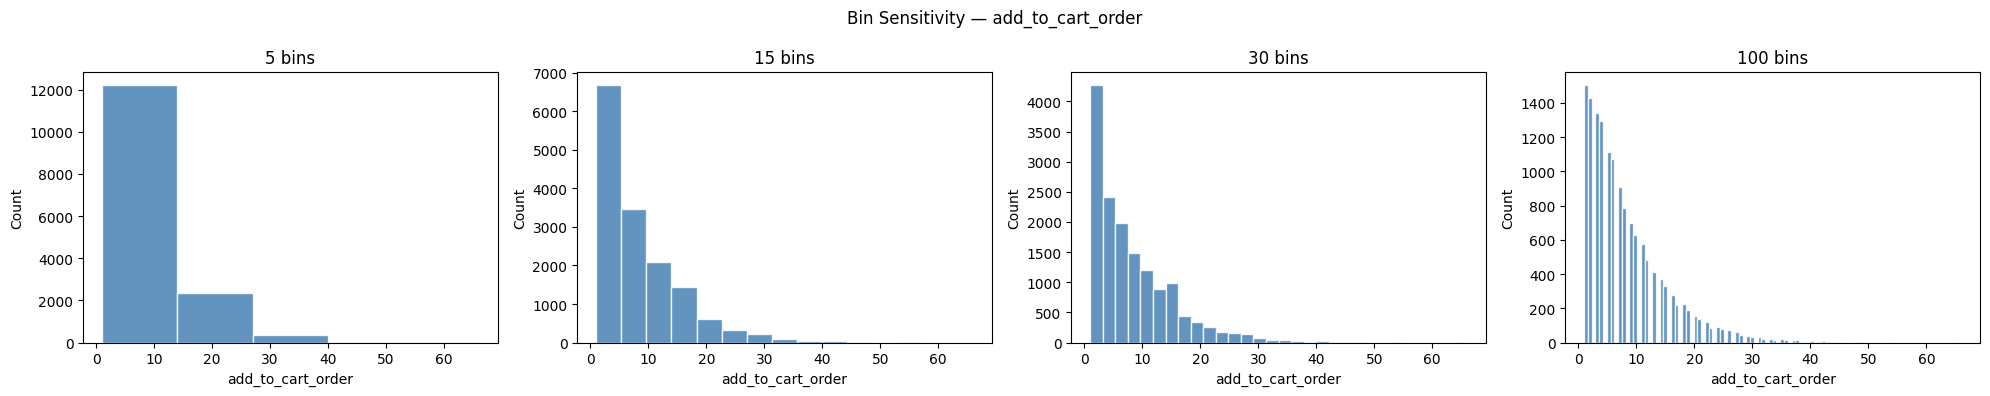

/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 63.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


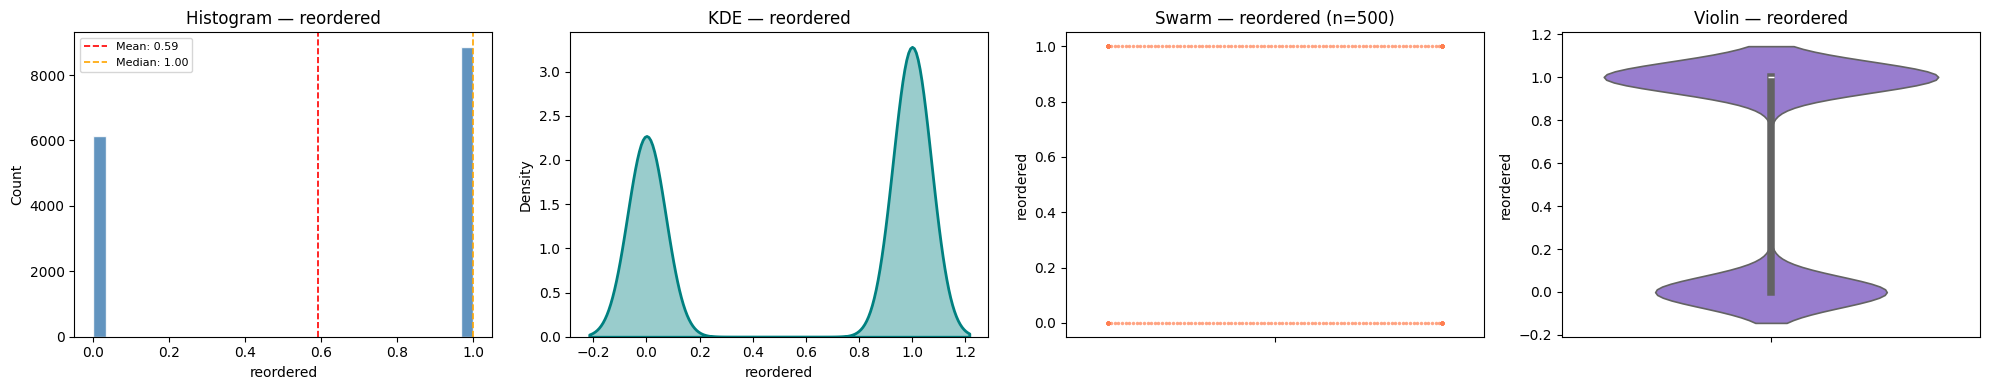

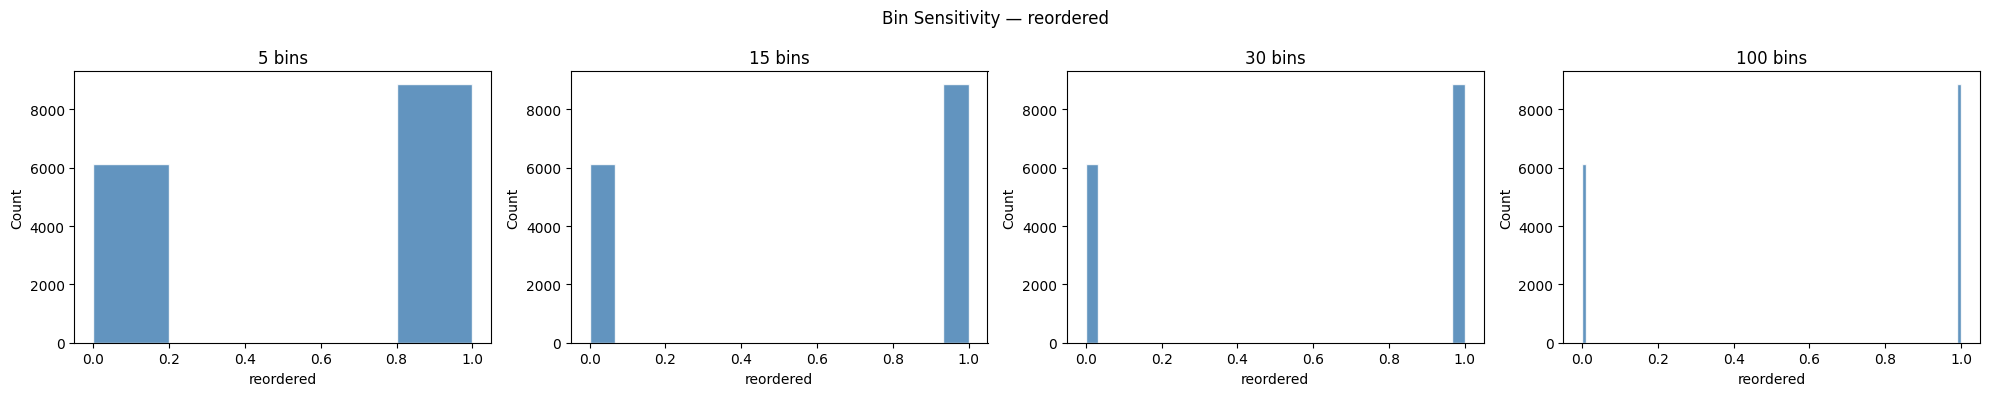


--- Categorical Features ---


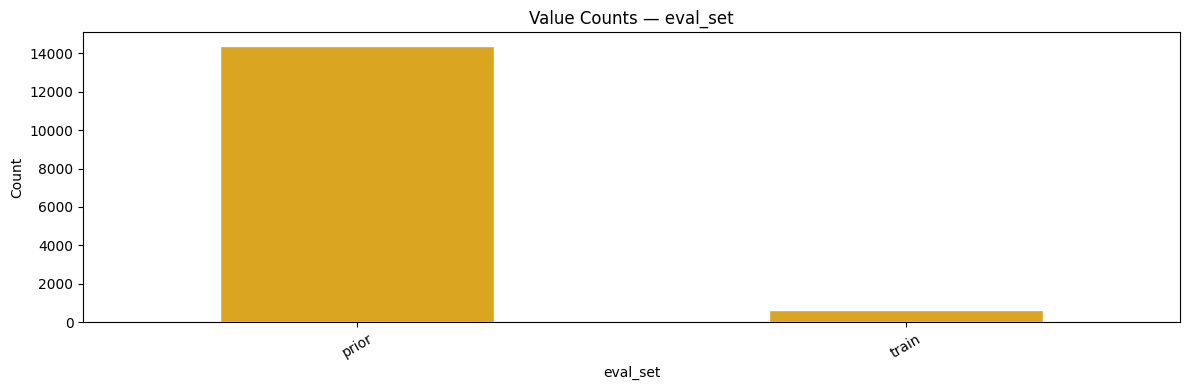

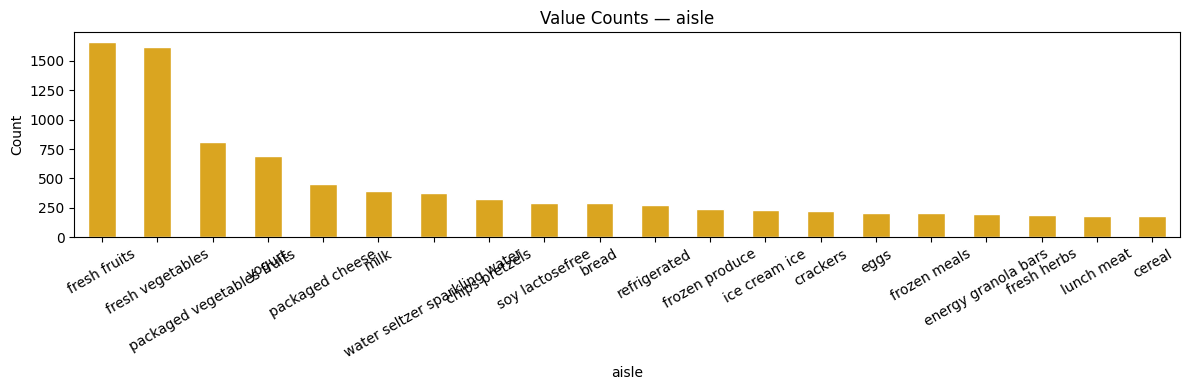

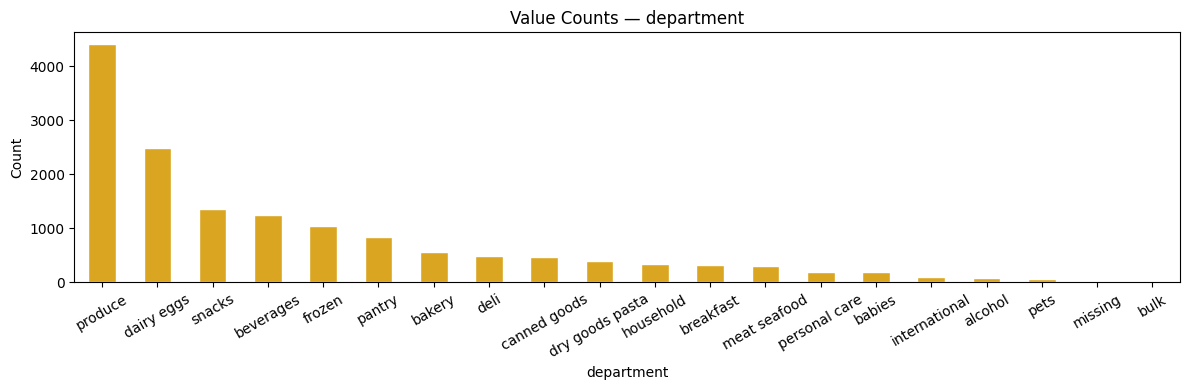


--- Grouped Features ---


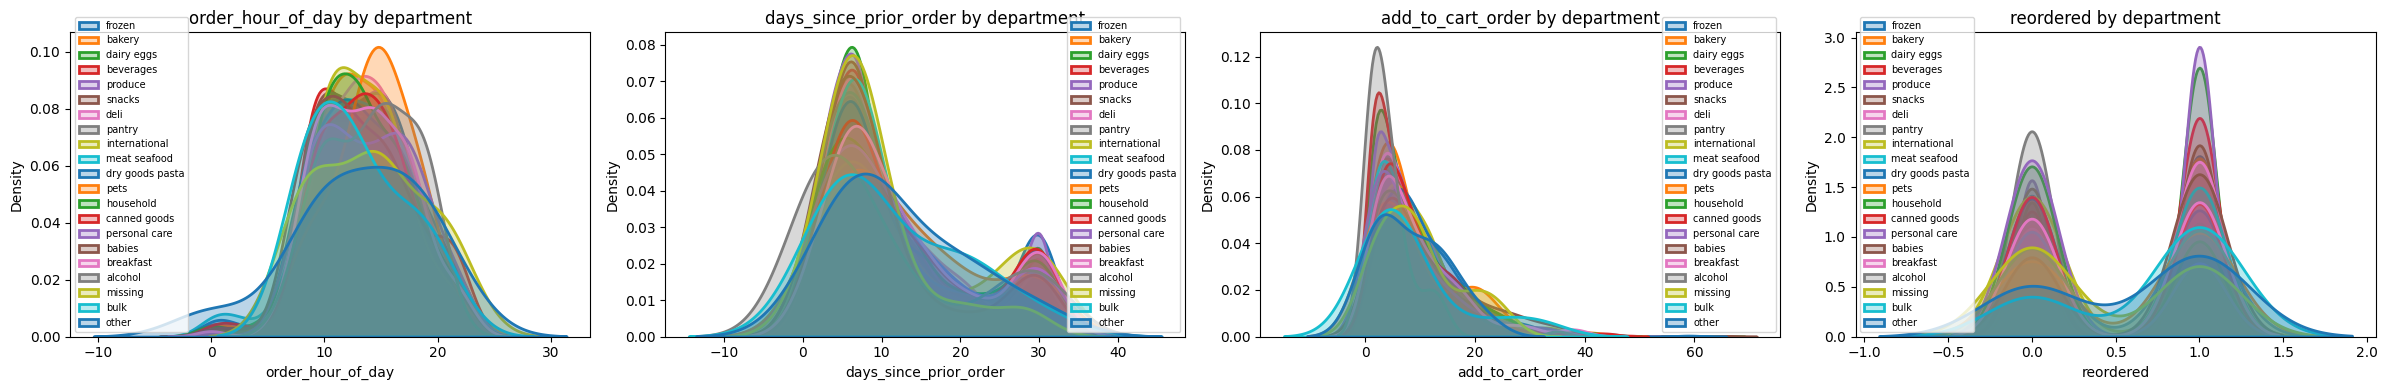

In [138]:

instacart_groupings = [
    ('order_hour_of_day', 'department'),
    ('days_since_prior_order', 'department'),
    ('add_to_cart_order', 'department'),
    ('reordered', 'department'),
]
analyze_dataset(df_instacart_sample,instacart_groupings, dataset_name='Instacart Records')

# Conclusions:

## Dataset 1: US E-Commerce

- Usable? Small dataset (3312 rows), limited for modeling. May need a larger dataset.
- Shape: Sales and Profit are heavily right-skewed. Discount is multimodal with fixed tiers.
- Outliers: Profit has large negative outliers driven by heavy discounting at 0.7/0.8 tiers.
- Across groups: Furniture and Office Supplies are most heavily discounted, driving losses. Regional and segment differences are minimal.
- Min/Max: look below
- Bin sizes: Discount best example — at low bins we might miss the multimodal structure, higher bins reveal the fixed pricing tiers clearly.
- Normal? No feature is normally distributed — all skewed or multimodal.

In [147]:
df = df_us_ecommerce_records_sample
cols = [col for col in df.select_dtypes(include='number').columns 
        if not any(p in col.lower() for p in skip_patterns)]

df[cols].describe().loc[['min', 'max']]

,Sales,Quantity,Discount,Profit
min,0.444,1.0,0.0,-3839.9904
max,13999.960,14.0,0.8,6719.9808


## Dataset 2: Instacart

- Usable? 3.3M rows, nulls on **`days_since_prior_order`** are expected and explainable. Good dataset.
- No sales/price data present 
  - recommendations can be built around purchase frequency, reorder behavior, and department/aisle groupings, but cannot be weighted by cart value or revenue impact.
- Shape: `order_hour_of_day` roughly normal. order_dow fairly uniform with weekend peak. add_to_cart and `days_since_prior_order` right-skewed.
- Outliers: High add_to_cart values (60+) exist but are expected for large orders.
- Across groups: Departments behave surprisingly similarly — need aisle\product level to find meaningful differences.
- Min/Max: look below
- Bin sizes: days_since_prior_order best example — 30-day spike only visible at higher bin counts.
- Normal? Only `order_hour_of_day`  approaches normal.

In [148]:
df = df_instacart_sample
cols = [col for col in df.select_dtypes(include='number').columns 
        if not any(p in col.lower() for p in skip_patterns)]

df[cols].describe().loc[['min', 'max']]

,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
min,0.0,0.0,0.0,1.0,0.0
max,6.0,23.0,30.0,66.0,1.0


# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

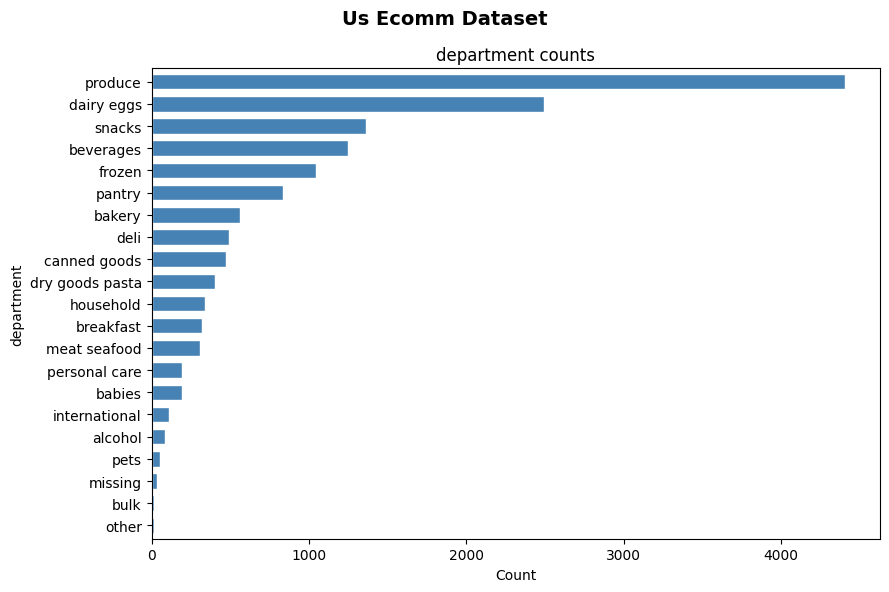

In [161]:
def plot_horizontal_bar(df, feature):
    fig, ax = plt.subplots(figsize=(9, 6))
    df[feature].value_counts().sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white', width=0.7)
    ax.set(title=f'{feature} counts', xlabel='Count', ylabel=feature)
    fig.suptitle('Us Ecomm Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_horizontal_bar(df_instacart_sample, 'department')

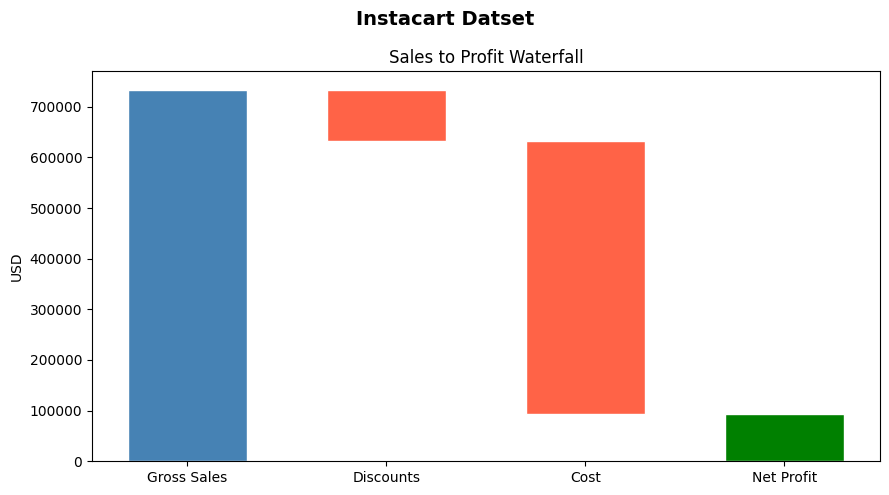

In [162]:
def plot_waterfall(df):
    total_sales = df['Sales'].sum()
    total_discount = (df['Sales'] * df['Discount']).sum()
    net_revenue = total_sales - total_discount
    total_profit = df['Profit'].sum()
    total_cost = net_revenue - total_profit

    values = [total_sales, -total_discount, -total_cost, total_profit]
    labels = ['Gross Sales', 'Discounts', 'Cost', 'Net Profit']
    running = [0, total_sales, total_sales - total_discount, net_revenue]

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['steelblue', 'tomato', 'tomato', 'green']
    running_total = 0
    for i, (val, label, color) in enumerate(zip(values, labels, colors)):
        if label in ['Gross Sales', 'Net Profit']:  # anchor bars start at 0
            ax.bar(label, abs(val), bottom=0, color=color, edgecolor='white', width=0.6)
        else:
            ax.bar(label, abs(val), bottom=running_total + val, color=color, edgecolor='white', width=0.6)
        running_total += val
    ax.set(title='Sales to Profit Waterfall', ylabel='USD')
    fig.suptitle('Instacart Datset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_waterfall(df_us_ecommerce_records_sample)

### AI Usage 
AI assisted with chart syntax, evaluating visualization options, and efficiently sampling a large dataset.
